# Tutorial 5 — From one sample to many

## 1. Problem / context

We have 180 thickness measurements. Management asks: “If we report the mean, how much would that mean jump if we repeated the whole sample?” That question is about the **sampling distribution** of $\bar{X}$, not about the histogram of a single sample.

## 2. Core theory

$\bar{X}=\frac1n\sum_{i=1}^n X_i$ is a random variable. If the $X_i$ are i.i.d. with mean $\mu$ and variance $\sigma^2$, then

$$
E[\bar{X}]=\mu,
\qquad
\operatorname{Var}(\bar{X})=\frac{\sigma^2}{n},
\qquad
\operatorname{SE}(\bar{X})=\frac{\sigma}{\sqrt{n}}.
$$

The **central limit theorem** says that for large $n$, $\bar{X}$ is approximately $N(\mu,\sigma^2/n)$. Write the **variance** $\sigma^2/n$ in the normal, and the standard error separately.

The CLT does **not** say that a large sample makes the original measurements normal.

## 3. From mathematics to Python

We simulate many samples of size $n$ from the observed thickness values (bootstrap-style resampling) or from a fitted model, store the means, and draw their histogram.

## 4. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())
x = pd.read_csv(DATA / "sensor_thickness.csv")["thickness_um"].to_numpy()

n = 30
n_rep = 2000
rng = np.random.default_rng(42)
means = np.array([rng.choice(x, size=n, replace=True).mean() for _ in range(n_rep)])

sigma = x.std(ddof=1)
se = sigma / np.sqrt(n)
print("Mean of sample means:", means.mean())
print("SD of sample means:", means.std(ddof=1))
print("Predicted SE = s/sqrt(n):", se)


Mean of sample means: 250.81947078333332
SD of sample means: 0.8625707046036848
Predicted SE = s/sqrt(n): 0.8780390901361734


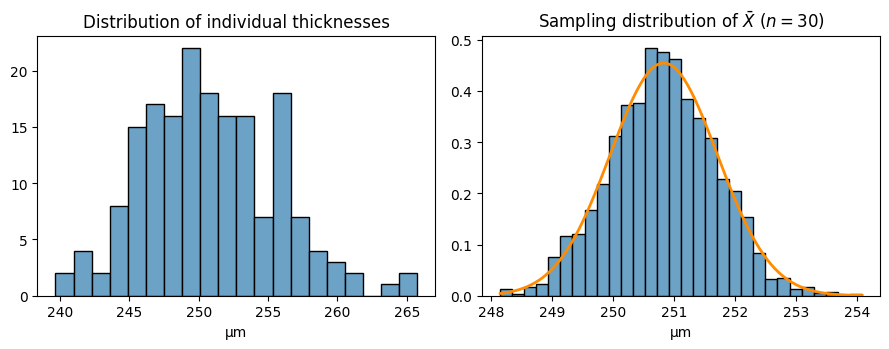

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].hist(x, bins=20, color="#6CA2C6", edgecolor="black")
axes[0].set_title("Distribution of individual thicknesses")
axes[0].set_xlabel("µm")

xs = np.linspace(means.min(), means.max(), 200)
axes[1].hist(means, bins=30, density=True, color="#6CA2C6", edgecolor="black")
axes[1].plot(xs, norm.pdf(xs, loc=x.mean(), scale=se), color="#FF8C00", lw=2)
axes[1].set_title(r"Sampling distribution of $\bar{X}$ ($n=30$)")
axes[1].set_xlabel("µm")
plt.tight_layout()
plt.show()


In [3]:
print("P(bar X > 251) approx", 1 - norm.cdf(251, loc=x.mean(), scale=se))


P(bar X > 251) approx 0.42339791736482313


## 5. Interpretation

The left histogram is about **plates**. The right histogram is about **means of 30 plates**. The right one is narrower by about $\sqrt{30}$ and closer to a normal curve. That is the CLT at work.

## 6. Common mistakes / things to notice

- Writing $\bar{X}\sim N(\mu,\sigma/\sqrt{n})$. Use $N(\mu,\sigma^2/n)$ and $\mathrm{SE}=\sigma/\sqrt{n}$.
- Saying “the data are normal because $n$ is large”.
- Using $n=2$ and expecting a beautiful bell curve.

## 7. Short worked example

If $\sigma=4.2$ µm and we want $\mathrm{SE}(\bar{X})\le 0.5$ µm, how large must $n$ be?


In [4]:
sigma = 4.2
n_needed = int(np.ceil((sigma / 0.5) ** 2))
print("n at least", n_needed)


n at least 71


**Conclusion in one sentence:** The uncertainty of a reported mean shrinks like $1/\sqrt{n}$; the CLT justifies a normal approximation for that mean even when a single thickness is only roughly bell-shaped.
